In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders       = pd.read_csv("../data/raw/instacart/orders.csv")
order_prior  = pd.read_csv("../data/raw/instacart/order_products__prior.csv")
order_train  = pd.read_csv("../data/raw/instacart/order_products__train.csv")
products     = pd.read_csv("../data/raw/instacart/products.csv")
aisles       = pd.read_csv("../data/raw/instacart/aisles.csv")
departments  = pd.read_csv("../data/raw/instacart/departments.csv")

print("orders:      ", orders.shape)
print("order_prior: ", order_prior.shape)
print("order_train: ", order_train.shape)
print("products:    ", products.shape)
print("aisles:      ", aisles.shape)
print("departments: ", departments.shape)


orders:       (3421083, 7)
order_prior:  (32434489, 4)
order_train:  (1384617, 4)
products:     (49688, 4)
aisles:       (134, 2)
departments:  (21, 2)


In [2]:
print("=== ORDERS ===")
print(orders.head(3))
print("\n=== ORDER_PRIOR ===")
print(order_prior.head(3))
print("\n=== PRODUCTS ===")
print(products.head(3))


=== ORDERS ===
   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  

=== ORDER_PRIOR ===
   order_id  product_id  add_to_cart_order  reordered
0         2       33120                  1          1
1         2       28985                  2          1
2         2        9327                  3          0

=== PRODUCTS ===
   product_id                          product_name  aisle_id  department_id
0           1            Chocolate Sandwich Cookies        61             19
1           2                      All-Seasons Salt       104             13
2           3  Robust Golden Unsweetened Oolong Tea        94              7


In [3]:
for name, df in [("orders", orders), ("order_prior", order_prior),
                 ("order_train", order_train), ("products", products)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    print(f"=== {name} ===")
    print(nulls if len(nulls) > 0 else "No nulls")
    print()


=== orders ===
days_since_prior_order    206209
dtype: int64

=== order_prior ===
No nulls

=== order_train ===
No nulls

=== products ===
No nulls



count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: order_id, dtype: float64

Users with only 1 order: 0
Users with 10+ orders: 110728


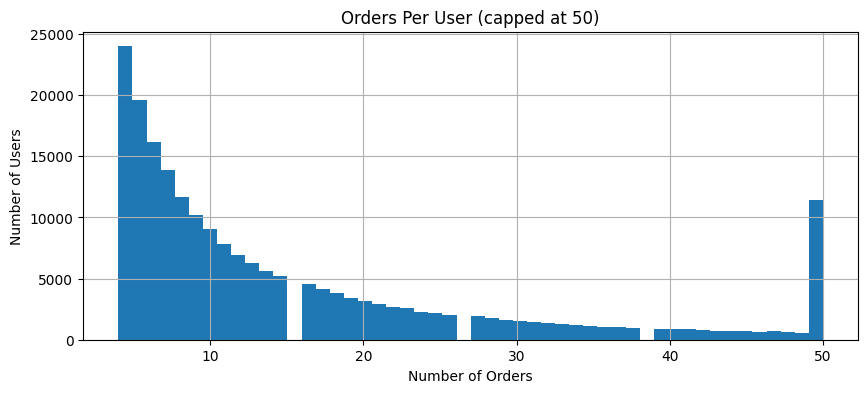

In [4]:
orders_per_user = orders.groupby("user_id")["order_id"].count()
print(orders_per_user.describe())
print("\nUsers with only 1 order:", (orders_per_user == 1).sum())
print("Users with 10+ orders:", (orders_per_user >= 10).sum())

plt.figure(figsize=(10, 4))
orders_per_user.clip(upper=50).hist(bins=50)
plt.title("Orders Per User (capped at 50)")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Users")
plt.show()


count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
Name: product_id, dtype: float64

Orders with 1 item: 156748


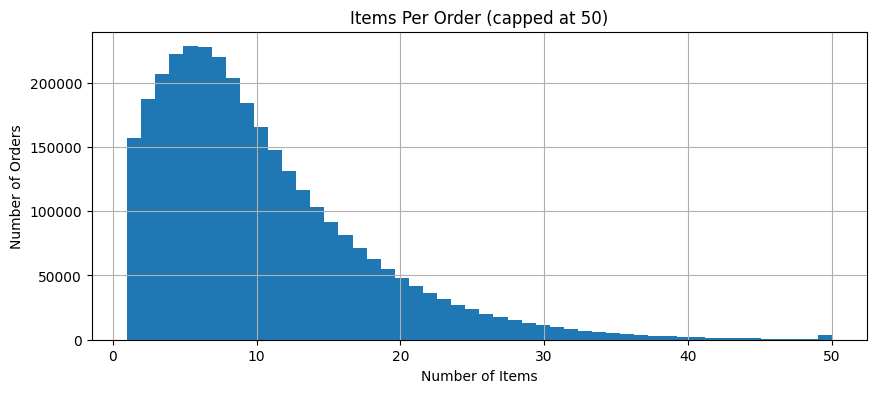

In [5]:
items_per_order = order_prior.groupby("order_id")["product_id"].count()
print(items_per_order.describe())
print("\nOrders with 1 item:", (items_per_order == 1).sum())

plt.figure(figsize=(10, 4))
items_per_order.clip(upper=50).hist(bins=50)
plt.title("Items Per Order (capped at 50)")
plt.xlabel("Number of Items")
plt.ylabel("Number of Orders")
plt.show()


In [6]:
print("Overall reorder rate:", order_prior["reordered"].mean().round(3))

top_products = (order_prior.groupby("product_id")["order_id"]
                .count().sort_values(ascending=False).head(10))
top_products = top_products.reset_index().merge(products, on="product_id")
print("\nTop 10 most ordered products:")
print(top_products[["product_name", "order_id"]])


Overall reorder rate: 0.59

Top 10 most ordered products:
             product_name  order_id
0                  Banana    472565
1  Bag of Organic Bananas    379450
2    Organic Strawberries    264683
3    Organic Baby Spinach    241921
4    Organic Hass Avocado    213584
5         Organic Avocado    176815
6             Large Lemon    152657
7            Strawberries    142951
8                   Limes    140627
9      Organic Whole Milk    137905


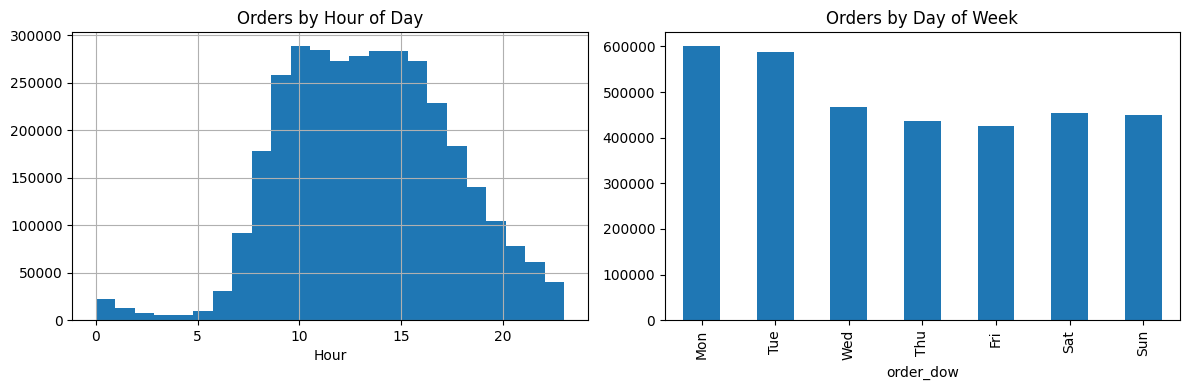

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

orders["order_hour_of_day"].hist(bins=24, ax=axes[0])
axes[0].set_title("Orders by Hour of Day")
axes[0].set_xlabel("Hour")

day_map = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
orders["order_dow"].map(day_map).value_counts().reindex(day_map.values()).plot(
    kind="bar", ax=axes[1])
axes[1].set_title("Orders by Day of Week")
plt.tight_layout()
plt.show()


In [8]:
print("=== ORDERS ===")
print(orders["eval_set"].value_counts())
print("\nTotal unique users:", orders["user_id"].nunique())
print("Total unique products:", products["product_id"].nunique())
print("Avg orders per user:", orders.groupby("user_id")["order_id"].count().mean().round(1))
print("Avg items per order:", order_prior.groupby("order_id")["product_id"].count().mean().round(1))

print("""
INSTACART EDA SUMMARY
=====================
- 3.4M orders, 206K users, 49K products
- 32.4M prior order-product pairs (training data)
- days_since_prior_order: 206K nulls = first orders → fill with 0
- eval_set 'test' has no product labels → drop
- 59% reorder rate → strong signal for recommendations
- Top products: fresh produce (Banana, Organic Bananas, etc.)

CLEANING PLAN:
- Fill days_since_prior_order nulls with 0
- Drop eval_set == 'test' rows
- Combine order_prior + order_train
- Join with products + aisles + departments
- Filter users with < 3 orders (not enough history)
- Save as interactions table for two-tower model
""")


=== ORDERS ===
eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64

Total unique users: 206209
Total unique products: 49688
Avg orders per user: 16.6
Avg items per order: 10.1

INSTACART EDA SUMMARY
- 3.4M orders, 206K users, 49K products
- 32.4M prior order-product pairs (training data)
- days_since_prior_order: 206K nulls = first orders → fill with 0
- eval_set 'test' has no product labels → drop
- 59% reorder rate → strong signal for recommendations
- Top products: fresh produce (Banana, Organic Bananas, etc.)

CLEANING PLAN:
- Fill days_since_prior_order nulls with 0
- Drop eval_set == 'test' rows
- Combine order_prior + order_train
- Join with products + aisles + departments
- Filter users with < 3 orders (not enough history)
- Save as interactions table for two-tower model

